# Product Customer Segmentation


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score



In [ ]:
df = pd.read_csv("/content/Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
print("Shape of dataset:", df.shape)
df.info()

Shape of dataset: (200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
print("Missing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicate rows: 0


In [ ]:

df.rename(columns={
    'Genre': 'Gender',
    'Annual Income (k$)': 'Annual_Income',
    'Spending Score (1-100)': 'Spending_Score'
}, inplace=True)
df.head()

,CustomerID,Gender,Age,Annual_Income,Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


 Exploratory Data Analysis (EDA)



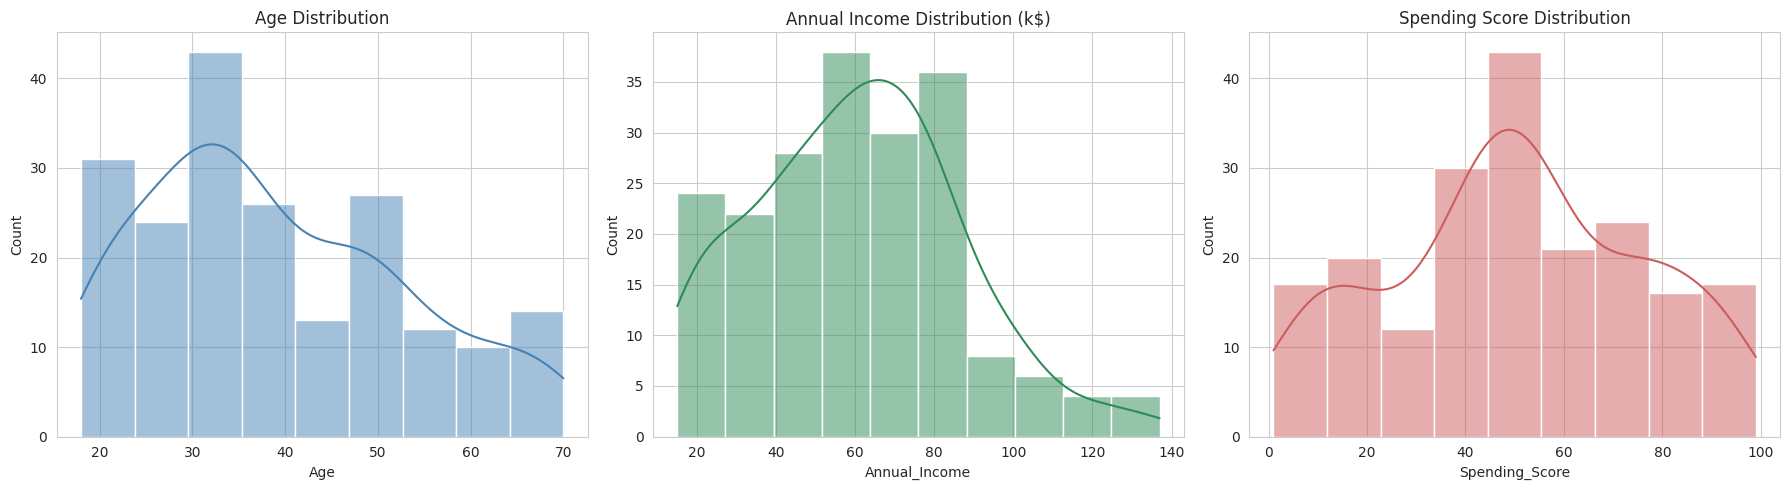

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))
sns.histplot(df['Age'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Age Distribution')

sns.histplot(df['Annual_Income'], kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('Annual Income Distribution (k$)')

sns.histplot(df['Spending_Score'], kde=True, ax=axes[2], color='indianred')
axes[2].set_title('Spending Score Distribution')

plt.tight_layout()
plt.show()

/tmp/ipykernel_770/1913698932.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=df, palette='pastel')


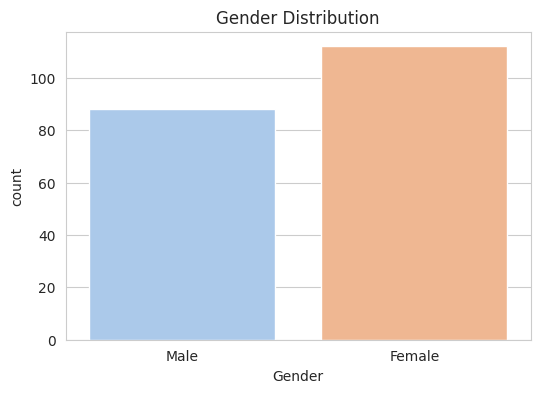

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df, palette='pastel')
plt.title('Gender Distribution')
plt.show()

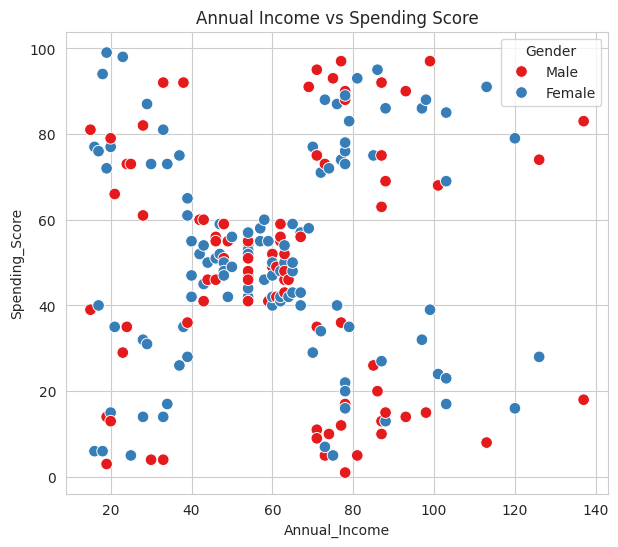

In [ ]:
plt.figure(figsize=(7,6))
sns.scatterplot(x='Annual_Income', y='Spending_Score', data=df, hue='Gender', palette='Set1', s=70)
plt.title('Annual Income vs Spending Score')
plt.show()

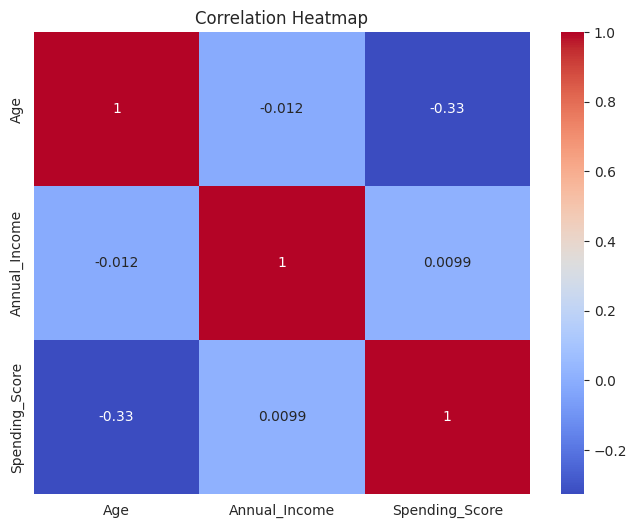

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['Age','Annual_Income','Spending_Score']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

 Feature Selection & Scaling


In [ ]:
X = df[['Annual_Income', 'Spending_Score']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:5]

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

Finding the Optimal Number of Clusters


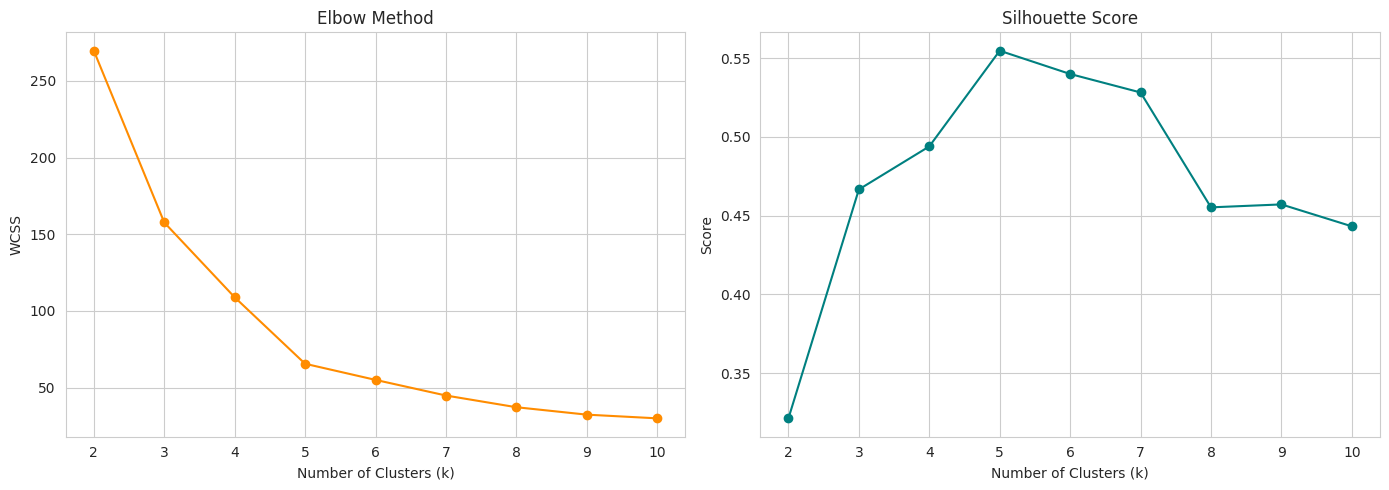

In [ ]:
wcss = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].plot(list(K_range), wcss, marker='o', color='darkorange')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('WCSS')

axes[1].plot(list(K_range), sil_scores, marker='o', color='teal')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Score')

plt.tight_layout()
plt.show()

**Observation:** The elbow bends around k=5, and the silhouette score also peaks near k=5. So we'll go with **5 clusters**.

## Step 7: Build the K-Means Model

In [ ]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)
df.head()

,CustomerID,Gender,Age,Annual_Income,Spending_Score,Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


## Step 8: Visualize the Clusters

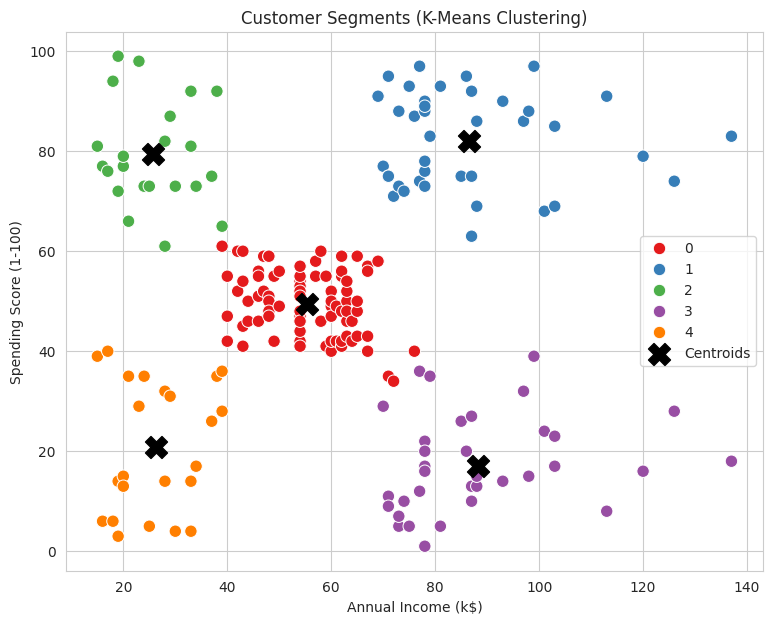

In [ ]:
plt.figure(figsize=(9,7))
sns.scatterplot(x='Annual_Income', y='Spending_Score', hue='Cluster', data=df, palette='Set1', s=80)

centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers[:,0], centers[:,1], s=250, c='black', marker='X', label='Centroids')

plt.title('Customer Segments (K-Means Clustering)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

 Cluster Interpretation



In [ ]:
cluster_summary = df.groupby('Cluster')[['Age','Annual_Income','Spending_Score']].mean().round(1)
cluster_summary['Count'] = df['Cluster'].value_counts().sort_index()
cluster_summary

,Age,Annual_Income,Spending_Score,Count
Cluster,,,,
0,42.7,55.3,49.5,81
1,32.7,86.5,82.1,39
2,25.3,25.7,79.4,22
3,41.1,88.2,17.1,35
4,45.2,26.3,20.9,23


In [ ]:
df.to_csv("Customer_Segments_Output.csv", index=False)
print("Saved: Customer_Segments_Output.csv")

Saved: Customer_Segments_Output.csv


In [ ]:
summary = df.groupby('Cluster')[['Age','Annual_Income','Spending_Score']].mean().round(1)
summary['Count'] = df['Cluster'].value_counts().sort_index()

segment_labels = {
    0: 'Average Customers',
    1: 'VIP / High-Value',
    2: 'Impulsive Spenders',
    3: 'Careful High-Earners',
    4: 'Budget Shoppers'
}
summary['Segment Label'] = summary.index.map(segment_labels)
print(summary.to_string())

          Age  Annual_Income  Spending_Score  Count         Segment Label
Cluster                                                                  
0        42.7           55.3            49.5     81     Average Customers
1        32.7           86.5            82.1     39      VIP / High-Value
2        25.3           25.7            79.4     22    Impulsive Spenders
3        41.1           88.2            17.1     35  Careful High-Earners
4        45.2           26.3            20.9     23       Budget Shoppers


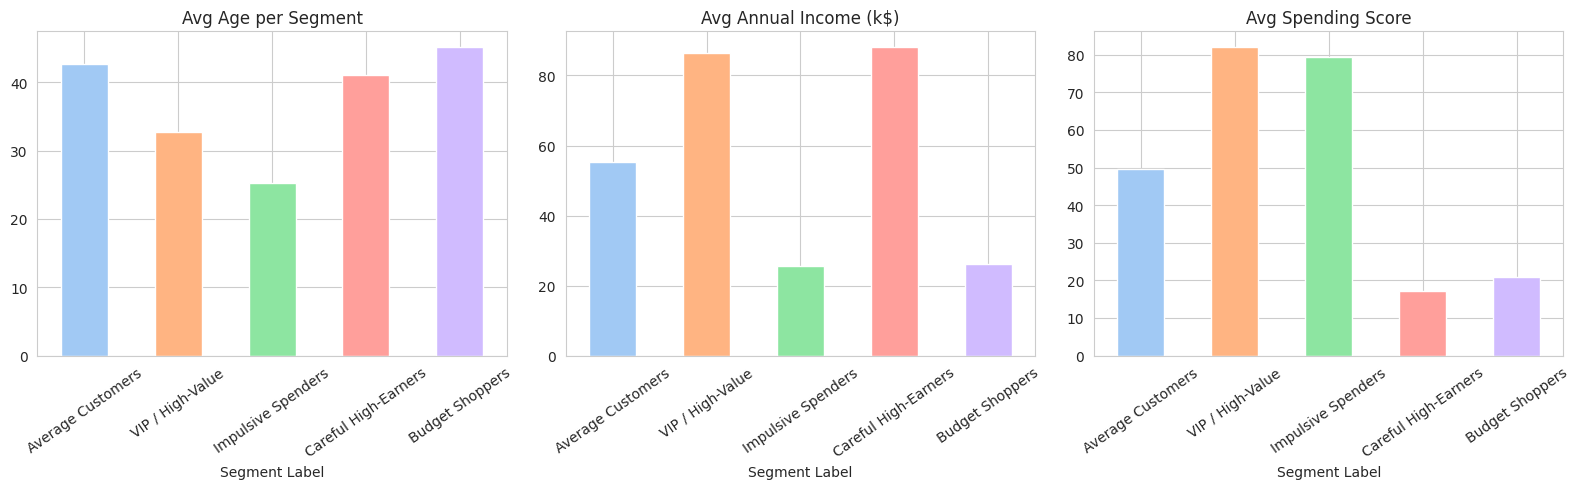

In [ ]:
summary_plot = summary.copy()
summary_plot.index = summary_plot['Segment Label']

colors = sns.color_palette('pastel', n_colors=len(summary))
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
summary_plot['Age'].plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Avg Age per Segment'); axes[0].tick_params(axis='x', rotation=35)
summary_plot['Annual_Income'].plot(kind='bar', ax=axes[1], color=colors, edgecolor='white')
axes[1].set_title('Avg Annual Income (k$)'); axes[1].tick_params(axis='x', rotation=35)
summary_plot['Spending_Score'].plot(kind='bar', ax=axes[2], color=colors, edgecolor='white')
axes[2].set_title('Avg Spending Score'); axes[2].tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()

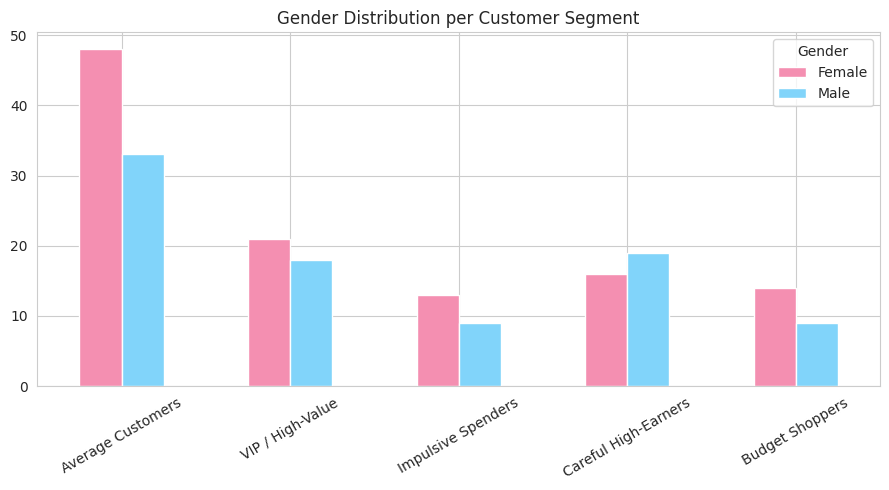

In [ ]:
gender_cluster = df.groupby(['Cluster','Gender']).size().unstack(fill_value=0)
gender_cluster.index = [segment_labels[i] for i in gender_cluster.index]
gender_cluster.plot(kind='bar', figsize=(9, 5), color=['#f48fb1','#81d4fa'], edgecolor='white')
plt.title('Gender Distribution per Customer Segment')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

| Segment | Characteristics | Recommended Strategy |
|---|---|---|
| VIP / High-Value | High income, high spending | Loyalty programs, premium perks, early access |
| Impulsive Spenders | Low income, high spending | Limited-time deals, EMI/instalment offers |
| Careful High-Earners | High income, low spending | Personalized recommendations, reviews, trust-building |
| Budget Shoppers | Low income, low spending | Discounts, value bundles, essential product deals |
| Average Customers | Medium income, medium spending | Seasonal offers, newsletters, standard engagement |

In [ ]:
df.to_csv("Customer_Segments_Output.csv", index=False)
print("Saved: Customer_Segments_Output.csv")
df[['CustomerID','Gender','Age','Annual_Income','Spending_Score','Cluster']].head(10)

Saved: Customer_Segments_Output.csv


,CustomerID,Gender,Age,Annual_Income,Spending_Score,Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4
5,6,Female,22,17,76,2
6,7,Female,35,18,6,4
7,8,Female,23,18,94,2
8,9,Male,64,19,3,4
9,10,Female,30,19,72,2
